In [134]:
import pandas as pd
import os

# Load CSV files
train_df = pd.read_csv('train.csv')

# Example: Get list of image paths
train_image_files = [os.path.join('train/', f) for f in os.listdir('train/')]

print(f"Found {len(train_image_files)} training images")

Found 15000 training images


In [135]:
print("Train data shape:", train_df.shape)
train_df.head()

Train data shape: (67914, 17)


,Unnamed: 0,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max,raw_x_min,raw_x_max,raw_y_min,raw_y_max,raw_width,raw_height,scale_x,scale_y
0,0,78aa8415fbf1c792f7d7c53349d44d4f,No finding,14,R16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000.0,3000.0,0.341333,0.341333
1,1,78aa8415fbf1c792f7d7c53349d44d4f,No finding,14,R17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000.0,3000.0,0.341333,0.341333
2,2,78aa8415fbf1c792f7d7c53349d44d4f,No finding,14,R11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000.0,3000.0,0.341333,0.341333
3,3,183015e171f5159d7e60d43578632a3f,Aortic enlargement,0,R8,567.0,295.0,671.0,417.0,1134.0,1342.0,721.0,1019.0,2048.0,2500.0,0.500000,0.409600
4,4,183015e171f5159d7e60d43578632a3f,Pleural thickening,11,R9,58.0,794.0,116.0,851.0,117.0,232.0,1938.0,2077.0,2048.0,2500.0,0.500000,0.409600


In [136]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

In [137]:
# Number of images per label
label_counts = train_df['class_name'].value_counts()
label_counts = label_counts.sort_index()
label_counts

class_name
Aortic enlargement     7162
Atelectasis             279
Calcification           960
Cardiomegaly           5427
Consolidation           556
ILD                    1000
Infiltration           1247
Lung Opacity           2483
No finding            31818
Nodule/Mass            2580
Other lesion           2203
Pleural effusion       2476
Pleural thickening     4842
Pneumothorax            226
Pulmonary fibrosis     4655
Name: count, dtype: int64

In [138]:
class_counts = train_df["class_name"].value_counts()

fig = px.bar(
    class_counts,
    x=class_counts.index,
    y=class_counts.values,
    log_y=True,
    color=class_counts.index

).update_layout(
    title="Number of annotations per class",
    xaxis_title="Class ID",
    yaxis_title="Number of observations",
).update_xaxes(categoryorder='total descending')
fig.show()

In [139]:
from collections import Counter

train_counter = Counter()
for class_id in train_df['class_id']:
    train_counter.update([class_id])

print("Number of classes:", len(train_counter))
print("Number of unique images:", train_df['image_id'].nunique())
print("Minimum number of images per class:", min(train_counter.values()))
print("Maximum number of images per class:", max(train_counter.values()))
print("Average number of images per class:", sum(train_counter.values()) / len(train_counter))

Number of classes: 15
Number of unique images: 15000
Minimum number of images per class: 226
Maximum number of images per class: 31818
Average number of images per class: 4527.6


In [140]:
majority_class = train_counter.most_common(1)[0]
print("Majority class:", majority_class[0])

baseline_acc = majority_class[1] / sum(train_counter.values())
print("Accuracy when always predicting the majority class:")
print(f"{baseline_acc:.2f} ({baseline_acc*100:.2f}%)")

Majority class: 14
Accuracy when always predicting the majority class:
0.47 (46.85%)


In [141]:
# Number of labels per image

image_label_counts = train_df['image_id'].value_counts()
image_label_counts = image_label_counts.sort_values(ascending=False)

print("Number of images with multiple labels:", (image_label_counts > 1).sum())
print("Maximum number of labels per image:", image_label_counts.max())
print("Average number of labels per image:", image_label_counts.mean())
print("Median number of labels per image:", image_label_counts.median())

Number of images with multiple labels: 15000
Maximum number of labels per image: 57
Average number of labels per image: 4.5276
Median number of labels per image: 3.0


In [142]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

def plot_image_with_bboxes(image_path, bboxes_df):
    """
    Plots an image with bounding boxes and class labels.
    
    Args:
        image_path (str): Path to the image file.
        bboxes_df (pd.DataFrame): DataFrame containing bounding box info for the image.
            Must contain columns: ['x_min', 'y_min', 'x_max', 'y_max', 'class_name']
    """
    # Load image
    img = Image.open(image_path)
    fig, ax = plt.subplots(1, figsize=(12, 12))
    ax.imshow(img)

    # Filter only rows with bounding boxes (exclude NaN boxes)
    bboxes = bboxes_df.dropna(subset=['x_min', 'y_min', 'x_max', 'y_max'])
    
    # Draw each bounding box
    for _, row in bboxes.iterrows():
        x_min, y_min = row['x_min'], row['y_min']
        width = row['x_max'] - x_min
        height = row['y_max'] - y_min
        class_name = row['class_name']
        
        # Create a Rectangle patch
        rect = patches.Rectangle(
            (x_min, y_min), width, height, 
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)
        
        # Label the box
        plt.text(
            x_min, y_min - 10, class_name, 
            color='yellow', fontsize=12, weight='bold',
            bbox=dict(facecolor='red', alpha=0.5)
        )

    plt.axis('off')
    plt.show()


In [143]:
import random
import numpy as np

In [144]:
import random
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

def display_random_images_with_bboxes(df, num_images=5, figsize=(15, 18)):
    # Filter dataframe to exclude images with only 'No finding'
    # Get image_ids that have at least one annotation other than "No finding"
    valid_image_ids = df.groupby('image_id').filter(
        lambda x: (x['class_name'] != 'No finding').any()
    )['image_id'].unique()
    
    print(f"Total unique images with findings: {len(valid_image_ids)}")
    
    # Select random images from valid ones
    if len(valid_image_ids) <= num_images:
        selected_ids = valid_image_ids
        print("Dataset has fewer images with findings than requested. Displaying all available images.")
    else:
        selected_ids = random.sample(list(valid_image_ids), num_images)
        print(f"Randomly selected {num_images} images with findings from dataset")
    
    # Create subplot grid
    fig, axes = plt.subplots(num_images, 1, figsize=figsize)
    
    # If only one image requested, make axes a list for consistent indexing
    if num_images == 1:
        axes = [axes]
    
    for i, image_id in enumerate(selected_ids):
        print(f"\n--- Image {i+1}/{len(selected_ids)} ---")
        ax = axes[i]
        
        try:
            image_df = df[df['image_id'] == image_id]
            if len(image_df) == 0:
                print(f"No annotations found for image ID: {image_id}")
                ax.text(0.5, 0.5, f"No annotations for image ID: {image_id}", 
                        ha='center', va='center', transform=ax.transAxes)
                continue
            
            image_path = "train/" + image_id + ".jpg"
            img = Image.open(image_path)
            img_array = np.array(img)
            ax.imshow(img_array)
            
            colors = ['r', 'g', 'b', 'c', 'm', 'y', 'orange', 'purple', 'brown', 'pink']
            classes = image_df['class_name'].unique()
            class_color_map = {cls: colors[i % len(colors)] for i, cls in enumerate(classes)}
            
            for _, row in image_df.iterrows():
                # Skip 'No finding' boxes explicitly, just in case
                if row['class_name'] == 'No finding':
                    continue
                
                x_min = row['x_min']
                y_min = row['y_min']
                x_max = row['x_max']
                y_max = row['y_max']
                width = x_max - x_min
                height = y_max - y_min
                
                class_name = row['class_name']
                color = class_color_map[class_name]
                
                rect = patches.Rectangle(
                    (x_min, y_min), width, height, 
                    linewidth=2, edgecolor=color, facecolor='none'
                )
                ax.add_patch(rect)
                
                ax.text(
                    x_min, y_min - 5, class_name, 
                    color=color, fontsize=10, 
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0)
                )
            
            ax.set_title(f"Image ID: {image_id} - {len(image_df[image_df['class_name'] != 'No finding'])} objects")
            ax.axis('off')
            
            print(f"Objects in image {image_id}:")
            class_summary = image_df[image_df['class_name'] != 'No finding']['class_name'].value_counts()
            for cls, count in class_summary.items():
                print(f"  - {cls}: {count}")
                
        except Exception as e:
            print(f"Error displaying image {image_id}: {str(e)}")
            ax.text(0.5, 0.5, f"Error loading image: {str(e)}", 
                    ha='center', va='center', transform=ax.transAxes)
    
    plt.tight_layout()
    plt.show()

Total unique images with findings: 4394
Randomly selected 5 images with findings from dataset

--- Image 1/5 ---
Objects in image 7310cb76b0642a868c3eb66ce74e7d70:
  - Cardiomegaly: 3
  - Other lesion: 1

--- Image 2/5 ---
Objects in image b065d3b4da92b8015b47224341661fd8:
  - Lung Opacity: 3
  - Infiltration: 3
  - Pleural effusion: 3
  - Nodule/Mass: 1
  - ILD: 1

--- Image 3/5 ---
Objects in image 6137da0107d18f2bc35b6814c0f00ac8:
  - Other lesion: 2
  - Calcification: 2
  - Aortic enlargement: 1
  - Lung Opacity: 1

--- Image 4/5 ---
Objects in image 80bd0e3e1fbd70822b77e8df2dd00ff2:
  - Pleural effusion: 3
  - Pneumothorax: 3
  - Pleural thickening: 1
  - Other lesion: 1

--- Image 5/5 ---
Objects in image 8596ba22a0324a295aa986fa60680492:
  - Other lesion: 2
  - Pleural effusion: 2
  - Aortic enlargement: 1
  - Pulmonary fibrosis: 1
  - Pleural thickening: 1


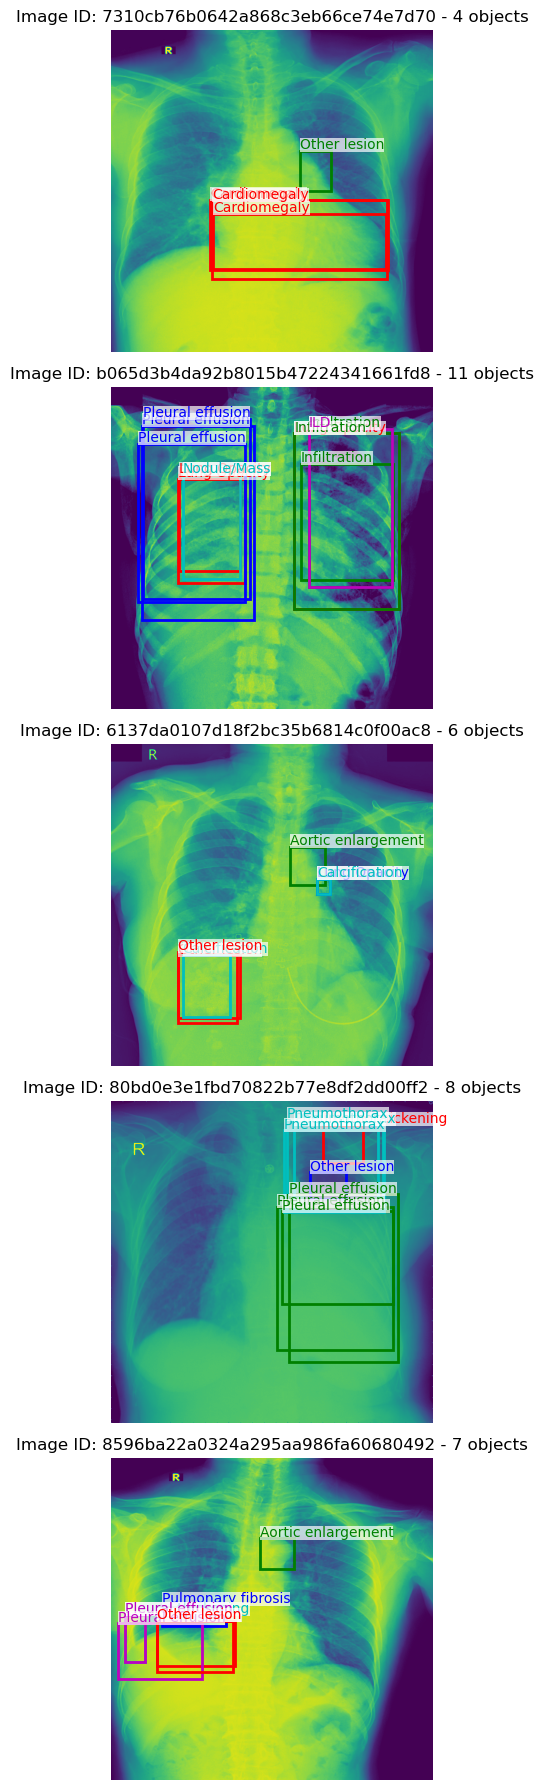

In [145]:
display_random_images_with_bboxes(train_df)

In [146]:
import pandas as pd
import numpy as np

def iou(box1, box2):
    """
    Calculate Intersection over Union of two boxes.
    Boxes are [x_min, y_min, x_max, y_max]
    """
    x_min = max(box1[0], box2[0])
    y_min = max(box1[1], box2[1])
    x_max = min(box1[2], box2[2])
    y_max = min(box1[3], box2[3])

    inter_area = max(0, x_max - x_min) * max(0, y_max - y_min)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union_area = box1_area + box2_area - inter_area
    if union_area == 0:
        return 0
    return inter_area / union_area

def nms_for_group(df, iou_threshold=0.5):
    """
    Apply Non-Max Suppression for boxes in one group (image_id + class_name).
    Assumes no scores, so keeps boxes in order they appear, removing overlaps > threshold.
    """
    boxes = df[['x_min', 'y_min', 'x_max', 'y_max']].values
    keep = []
    suppressed = [False] * len(boxes)

    for i in range(len(boxes)):
        if suppressed[i]:
            continue
        keep.append(i)
        for j in range(i+1, len(boxes)):
            if suppressed[j]:
                continue
            if iou(boxes[i], boxes[j]) > iou_threshold:
                suppressed[j] = True

    return df.iloc[keep]

def apply_nms(df, iou_threshold=0.5):
    """
    Apply NMS on the entire dataframe grouped by image_id and class_name.
    """
    dfs = []
    grouped = df.groupby(['image_id', 'class_name'])
    for (image_id, class_name), group in grouped:
        # Drop rows with NaN bboxes (e.g., 'No finding')
        group = group.dropna(subset=['x_min', 'y_min', 'x_max', 'y_max'])
        if len(group) == 0:
            continue
        kept = nms_for_group(group, iou_threshold)
        dfs.append(kept)
    
    # Concatenate all kept boxes
    cleaned_df = pd.concat(dfs).reset_index(drop=True)

    # Include rows with 'No finding' or without bbox (x_min NaN)
    no_bbox = df[df['x_min'].isna()]
    cleaned_df = pd.concat([cleaned_df, no_bbox]).reset_index(drop=True)
    
    return cleaned_df

# Usage example:

# Assuming train_df is your original dataframe
iou_threshold = 0.5  # Adjust threshold as needed
cleaned_train_df = apply_nms(train_df, iou_threshold)

# Save the cleaned dataframe
cleaned_train_df.to_csv("train_df_nms_cleaned.csv", index=False)
print("Saved cleaned dataframe with NMS applied.")


Saved cleaned dataframe with NMS applied.


In [147]:
df = pd.read_csv('train_df_nms_cleaned.csv')
print('shape=',df.shape)
df.head(20)

shape= (55828, 17)


,Unnamed: 0,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max,raw_x_min,raw_x_max,raw_y_min,raw_y_max,raw_width,raw_height,scale_x,scale_y
0,24710,0005e8e3701dfb1dd93d53e2ff537b6e,Consolidation,4,R8,311.0,189.0,399.0,299.0,932.0,1197.0,567.0,896.0,3072.0,3072.0,0.333333,0.333333
1,24708,0005e8e3701dfb1dd93d53e2ff537b6e,Infiltration,6,R10,300.0,196.0,402.0,296.0,900.0,1205.0,587.0,888.0,3072.0,3072.0,0.333333,0.333333
2,24706,0005e8e3701dfb1dd93d53e2ff537b6e,Lung Opacity,7,R10,300.0,196.0,402.0,296.0,900.0,1205.0,587.0,888.0,3072.0,3072.0,0.333333,0.333333
3,24707,0005e8e3701dfb1dd93d53e2ff537b6e,Nodule/Mass,8,R8,311.0,189.0,399.0,299.0,932.0,1197.0,567.0,896.0,3072.0,3072.0,0.333333,0.333333
4,5123,0007d316f756b3fa0baea2ff514ce945,Aortic enlargement,0,R10,567.0,369.0,666.0,441.0,1275.0,1498.0,1039.0,1241.0,2304.0,2880.0,0.444444,0.355556
5,5120,0007d316f756b3fa0baea2ff514ce945,Cardiomegaly,3,R10,401.0,650.0,813.0,724.0,902.0,1829.0,1827.0,2037.0,2304.0,2880.0,0.444444,0.355556
6,5124,0007d316f756b3fa0baea2ff514ce945,ILD,5,R9,821.0,501.0,930.0,745.0,1847.0,2093.0,1409.0,2096.0,2304.0,2880.0,0.444444,0.355556
7,5125,0007d316f756b3fa0baea2ff514ce945,ILD,5,R9,238.0,622.0,414.0,716.0,535.0,932.0,1748.0,2013.0,2304.0,2880.0,0.444444,0.355556
8,5119,0007d316f756b3fa0baea2ff514ce945,Pleural thickening,11,R10,364.0,241.0,439.0,334.0,818.0,987.0,677.0,939.0,2304.0,2880.0,0.444444,0.355556
9,5121,0007d316f756b3fa0baea2ff514ce945,Pleural thickening,11,R8,276.0,239.0,456.0,303.0,621.0,1025.0,673.0,851.0,2304.0,2880.0,0.444444,0.355556


Total unique images with findings: 4394
Randomly selected 5 images with findings from dataset

--- Image 1/5 ---
Objects in image 7882c56e6d4e2ec8b97556d8cfce4cf0:
  - Aortic enlargement: 1
  - Cardiomegaly: 1

--- Image 2/5 ---
Objects in image c37c1b0387090f95fa7f6b38542f1d19:
  - Consolidation: 1
  - Other lesion: 1
  - Pneumothorax: 1

--- Image 3/5 ---
Objects in image aae2c7e023bb6b4d9df30fda884d7b15:
  - Aortic enlargement: 1
  - Cardiomegaly: 1

--- Image 4/5 ---
Objects in image 5d911ff93f3820e66d76ffe822300426:
  - Lung Opacity: 3
  - Calcification: 2
  - ILD: 2
  - Infiltration: 1

--- Image 5/5 ---
Objects in image 59782bef0d73440e75ec2f92b4d4e38d:
  - Pleural thickening: 2
  - Aortic enlargement: 1
  - Cardiomegaly: 1


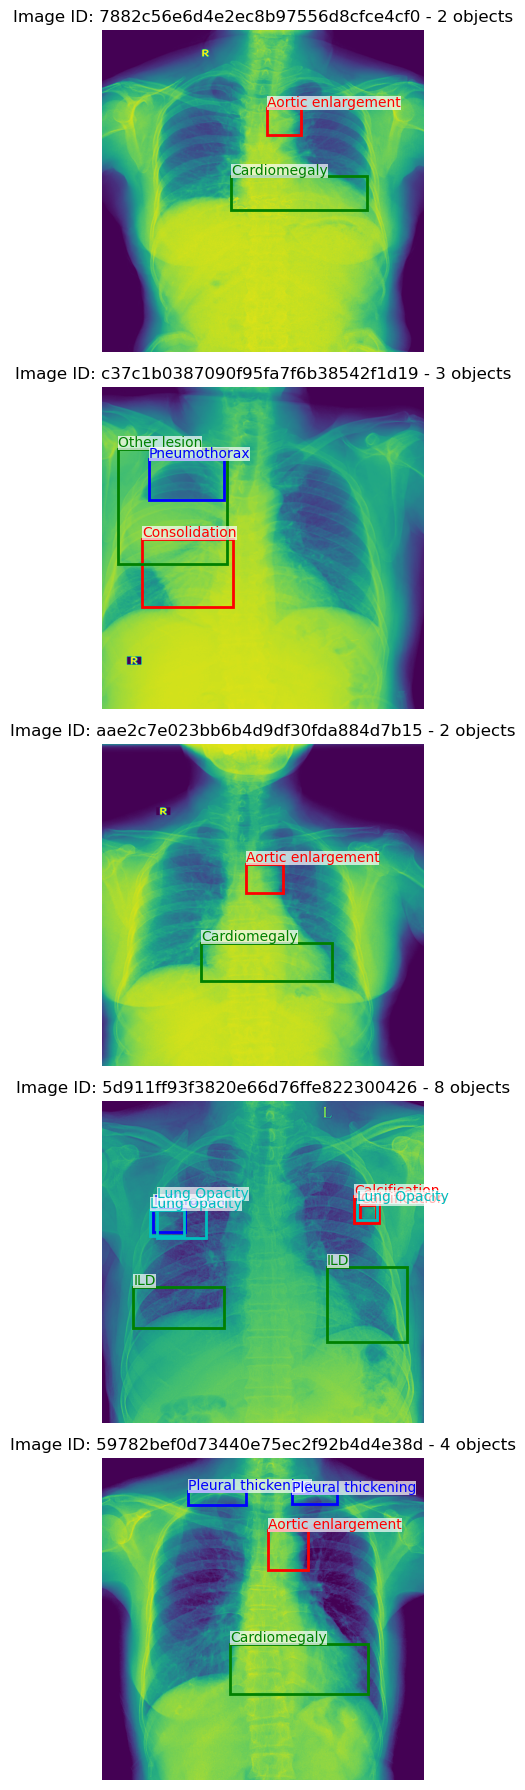

In [148]:
display_random_images_with_bboxes(df)

In [149]:
# Define minimum box size threshold
MIN_BOX_SIZE = 10

# Calculate box width and height if not already calculated
df['box_width'] = df['x_max'] - df['x_min']
df['box_height'] = df['y_max'] - df['y_min']

# Filter to keep only boxes with width and height >= MIN_BOX_SIZE
filtered_df = df[
    (df['box_width'] >= MIN_BOX_SIZE) & 
    (df['box_height'] >= MIN_BOX_SIZE) | 
    (df['x_min'].isna())  # Keep rows with NaN coords (e.g., 'No finding')
].copy()

# Drop the auxiliary columns if you want
filtered_df = filtered_df.drop(columns=['box_width', 'box_height'])

# Save cleaned dataframe
filtered_df.to_csv('train_df_no_small_boxes_and_nms.csv', index=False)
print(f"Saved cleaned dataframe without very small boxes. Rows before: {len(df)}, after: {len(filtered_df)}")

Saved cleaned dataframe without very small boxes. Rows before: 55828, after: 55739


In [150]:
df = pd.read_csv('train_df_no_small_boxes_and_nms.csv')
print('shape=',df.shape)
df.head(20)

shape= (55739, 17)


,Unnamed: 0,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max,raw_x_min,raw_x_max,raw_y_min,raw_y_max,raw_width,raw_height,scale_x,scale_y
0,24710,0005e8e3701dfb1dd93d53e2ff537b6e,Consolidation,4,R8,311.0,189.0,399.0,299.0,932.0,1197.0,567.0,896.0,3072.0,3072.0,0.333333,0.333333
1,24708,0005e8e3701dfb1dd93d53e2ff537b6e,Infiltration,6,R10,300.0,196.0,402.0,296.0,900.0,1205.0,587.0,888.0,3072.0,3072.0,0.333333,0.333333
2,24706,0005e8e3701dfb1dd93d53e2ff537b6e,Lung Opacity,7,R10,300.0,196.0,402.0,296.0,900.0,1205.0,587.0,888.0,3072.0,3072.0,0.333333,0.333333
3,24707,0005e8e3701dfb1dd93d53e2ff537b6e,Nodule/Mass,8,R8,311.0,189.0,399.0,299.0,932.0,1197.0,567.0,896.0,3072.0,3072.0,0.333333,0.333333
4,5123,0007d316f756b3fa0baea2ff514ce945,Aortic enlargement,0,R10,567.0,369.0,666.0,441.0,1275.0,1498.0,1039.0,1241.0,2304.0,2880.0,0.444444,0.355556
5,5120,0007d316f756b3fa0baea2ff514ce945,Cardiomegaly,3,R10,401.0,650.0,813.0,724.0,902.0,1829.0,1827.0,2037.0,2304.0,2880.0,0.444444,0.355556
6,5124,0007d316f756b3fa0baea2ff514ce945,ILD,5,R9,821.0,501.0,930.0,745.0,1847.0,2093.0,1409.0,2096.0,2304.0,2880.0,0.444444,0.355556
7,5125,0007d316f756b3fa0baea2ff514ce945,ILD,5,R9,238.0,622.0,414.0,716.0,535.0,932.0,1748.0,2013.0,2304.0,2880.0,0.444444,0.355556
8,5119,0007d316f756b3fa0baea2ff514ce945,Pleural thickening,11,R10,364.0,241.0,439.0,334.0,818.0,987.0,677.0,939.0,2304.0,2880.0,0.444444,0.355556
9,5121,0007d316f756b3fa0baea2ff514ce945,Pleural thickening,11,R8,276.0,239.0,456.0,303.0,621.0,1025.0,673.0,851.0,2304.0,2880.0,0.444444,0.355556


In [151]:
class_counts = df["class_name"].value_counts()

fig = px.bar(
    class_counts,
    x=class_counts.index,
    y=class_counts.values,
    log_y=True,
    color=class_counts.index

).update_layout(
    title="Number of annotations per class",
    xaxis_title="Class ID",
    yaxis_title="Number of observations",
).update_xaxes(categoryorder='total descending')
fig.show()

In [152]:
def undersample_no_finding(df, target_fraction=0.3, random_state=42):
    # Separate "No finding" and other classes
    no_finding_df = df[df['class_name'] == 'No finding']
    other_df = df[df['class_name'] != 'No finding']
    
    # Calculate how many "No finding" samples to keep
    target_n = int(len(other_df) * target_fraction / (1 - target_fraction))
    
    # Randomly sample "No finding" without replacement
    no_finding_sampled = no_finding_df.sample(
        min(target_n, len(no_finding_df)), 
        random_state=random_state
    )
    
    return pd.concat([other_df, no_finding_sampled], ignore_index=True)

In [153]:
df = undersample_no_finding(df, target_fraction=0.5)

In [154]:
def remove_minority_classes(df, min_samples=500):
    """
    Drops classes with fewer than `min_samples` annotations.
    """
    class_counts = df['class_name'].value_counts()
    valid_classes = class_counts[class_counts >= min_samples].index.tolist()
    return df[df['class_name'].isin(valid_classes)].copy()

# Keep only classes with ≥100 samples (adjust threshold)
df = remove_minority_classes(df, min_samples=500)

In [155]:
class_counts = df["class_name"].value_counts()

fig = px.bar(
    class_counts,
    x=class_counts.index,
    y=class_counts.values,
    log_y=True,
    color=class_counts.index

).update_layout(
    title="Number of annotations per class",
    xaxis_title="Class ID",
    yaxis_title="Number of observations",
).update_xaxes(categoryorder='total descending')
fig.show()

In [156]:
print(df['class_name'].unique())
print(df.shape)

['Infiltration' 'Lung Opacity' 'Nodule/Mass' 'Aortic enlargement'
 'Cardiomegaly' 'ILD' 'Pleural thickening' 'Pulmonary fibrosis'
 'Other lesion' 'Pleural effusion' 'Calcification' 'No finding']
(47042, 17)


In [157]:
df.to_csv('main_processed_df.csv', index=False)